In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.integrate import simpson
import csv

plt.style.use('sty.mplstyle')

# BNB flux at MiniBooNE

In [2]:
Elow_MiniBooNE = np.loadtxt("../csv/Fluxes/MiniBooNE_Fluxes_NuMode.dat.txt", usecols=0, comments="#") # Lower bin edge in GeV
Ehigh_MiniBooNE = np.loadtxt("../csv/Fluxes/MiniBooNE_Fluxes_NuMode.dat.txt", usecols=1, comments="#") # Upper bin edge in GeV
numu_flux_MiniBooNE = np.loadtxt("../csv/Fluxes/MiniBooNE_Fluxes_NuMode.dat.txt", usecols=2, comments="#") # numu/cm^2/POT/50 MeV

numu_flux_MiniBooNE = numu_flux_MiniBooNE*(1e7/50) # numu/m^2/POT/GeV
Enu_MiniBooNE = (Elow_MiniBooNE + Ehigh_MiniBooNE)/2

In [3]:
total_flux_MiniBooNE = simpson(numu_flux_MiniBooNE, Elow_MiniBooNE)
P_norm_MiniBooNE = np.zeros_like(numu_flux_MiniBooNE)

for i in range(len(numu_flux_MiniBooNE)):
    bin_width = Ehigh_MiniBooNE[i] - Elow_MiniBooNE[i]
    P_norm_MiniBooNE[i] = numu_flux_MiniBooNE[i]*bin_width/total_flux_MiniBooNE

In [4]:
# Writing to CSV
with open("../csv/Fluxes/NormProb/NormProb_BNB_MiniBooNE.txt", mode='w', newline="") as file:
    for e_low, e_high, p_norm in (zip(Elow_MiniBooNE, Ehigh_MiniBooNE, P_norm_MiniBooNE)):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

- Total flux ($E_{\mathrm{low}}$) =  5.188231179736934e-06
- Total flux ($E_{\mathrm{high}}$) = 5.188231179736933e-06
- Total flux ($E_{1/2}$) = 5.188231179736934e-06

# BNB flux at SBND

In [5]:
Elow_SBND = np.loadtxt("../csv/Fluxes/SBND_Fluxes_NeutrinoMode.dat", usecols=0, comments="#") # Lower bin edge in GeV
Ehigh_SBND = np.loadtxt("../csv/Fluxes/SBND_Fluxes_NeutrinoMode.dat", usecols=1, comments="#") # Upper bin edge in GeV
numu_flux_SBND = np.loadtxt("../csv/Fluxes/SBND_Fluxes_NeutrinoMode.dat", usecols=2, comments="#") # nu/m^2/10^6 POT/50 MeV

numu_flux_SBND = numu_flux_SBND*(1e-3/50) # numu/m^2/POT/GeV
Enu_SBND = (Elow_SBND + Ehigh_SBND)/2

In [6]:
total_flux_SBND = simpson(numu_flux_SBND, Ehigh_SBND)
P_norm_SBND = np.zeros_like(numu_flux_SBND)

for i in range(len(numu_flux_SBND)):
    bin_width = Ehigh_SBND[i] - Elow_SBND[i]
    P_norm_SBND[i] = numu_flux_SBND[i]*bin_width/total_flux_SBND

In [7]:
# Writing to CSV
with open("../csv/Fluxes/NormProb/NormProb_BNB_SBND.txt", mode='w', newline="") as file:
    for e_low, e_high, p_norm in zip(Elow_SBND, Ehigh_SBND, P_norm_SBND):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

- Total flux ($E_{\mathrm{low}}$) =  0.00016114069432666668
- Total flux ($E_{\mathrm{high}}$) = 0.00016114069432666668
- Total flux ($E_{1/2}$) = 0.00016114069432666668

# Plotting the Fluxes

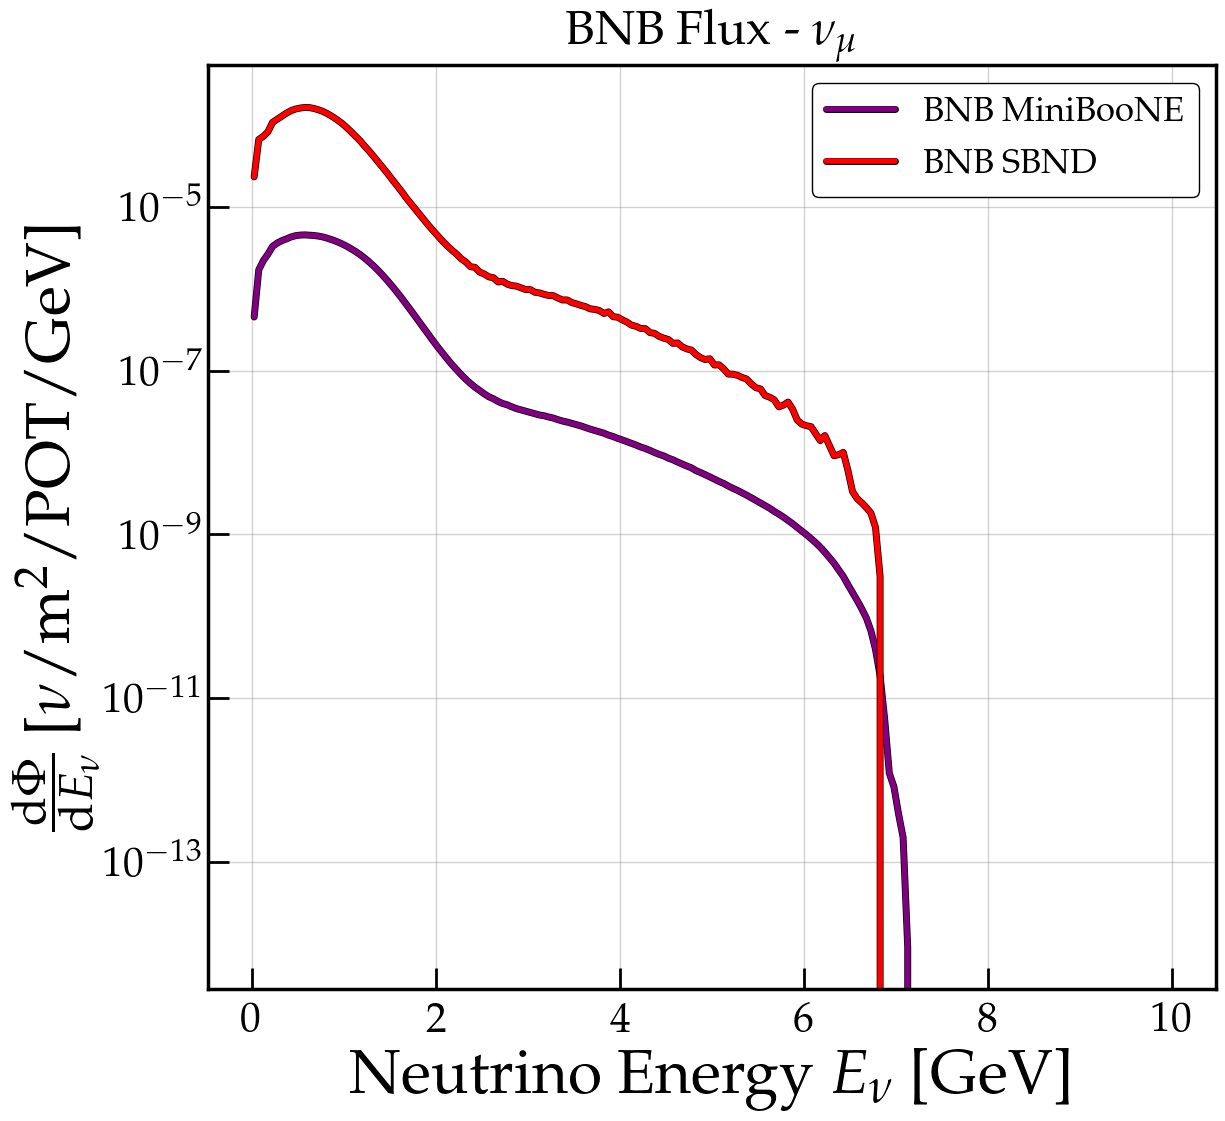

In [8]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Enu_MiniBooNE, numu_flux_MiniBooNE, color='purple', lw=4, label='BNB MiniBooNE', path_effects=[pe.Stroke(linewidth=5, foreground='k'), pe.Normal()])
ax.plot(Enu_SBND, numu_flux_SBND, color='red', lw=4, label='BNB SBND', path_effects=[pe.Stroke(linewidth=5, foreground='k'), pe.Normal()])

ax.set_yscale('log')
ax.xaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)
ax.yaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)
ax.legend(fontsize=25, loc='upper right', frameon=True, framealpha=1, edgecolor='k', fancybox=True)
ax.tick_params(which='both', right=False, top=False)
ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')
ax.set_ylabel(r'$\frac{\mathrm{d} \Phi}{\mathrm{d} E_\nu}$  [$\nu$/m$^2$/POT/GeV]')
ax.set_title(r'BNB Flux - $\nu_\mu$', pad=15)

plt.savefig('../Plots/Figures_PDF/BNBflux_MiniBooNE+SBND.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/BNBflux_MiniBooNE+SBND.png', transparent=False, bbox_inches='tight')

# Standard and Tau-Optimized Flux at DUNE

In [9]:
Enu_Std_DUNE = np.loadtxt("../csv/Fluxes/histos_g4lbne_v3r5p4_QGSP_BERT_OptimizedEngineeredNov2017_neutrino_LBNEND_globes_flux.txt", usecols=0, comments="#")
numu_flux_Std_DUNE = np.loadtxt("../csv/Fluxes/histos_g4lbne_v3r5p4_QGSP_BERT_OptimizedEngineeredNov2017_neutrino_LBNEND_globes_flux.txt", usecols=2, comments="#") # nu/m^2/POT/GeV

In [10]:
Elow_Std_DUNE = Enu_Std_DUNE - 0.25/2
Ehigh_Std_DUNE = Enu_Std_DUNE + 0.25/2
total_flux_Std_DUNE = simpson(numu_flux_Std_DUNE, Enu_Std_DUNE)
P_norm_Std_DUNE = np.zeros_like(numu_flux_Std_DUNE)

for i in range(len(numu_flux_Std_DUNE)):
    bin_width = Enu_Std_DUNE[1] - Enu_Std_DUNE[0]
    P_norm_Std_DUNE[i] = numu_flux_Std_DUNE[i]*bin_width/total_flux_Std_DUNE

In [11]:
# Writing to CSV
with open("../csv/Fluxes/NormProb/NormProb_DUNE_Standard.txt", mode='w', newline="") as file:
    for e_low, e_high, p_norm in zip(Elow_Std_DUNE, Ehigh_Std_DUNE, P_norm_Std_DUNE):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n") 

- Total flux (Standard) = 0.0010438734424042

In [12]:
Enu_TOPT_DUNE = np.loadtxt("../csv/Fluxes/histos_g4lbne_v3r5p4_QGSP_BERT_TauOptimized_neutrino_LBNEND_globes_flux.txt", usecols=0, comments="#")
numu_flux_TOPT_DUNE = np.loadtxt("../csv/Fluxes/histos_g4lbne_v3r5p4_QGSP_BERT_TauOptimized_neutrino_LBNEND_globes_flux.txt", usecols=2, comments="#") # nu/m^2/POT/GeV

In [13]:
Elow_TOPT_DUNE = Enu_TOPT_DUNE - 0.25/2
Ehigh_TOPT_DUNE = Enu_TOPT_DUNE + 0.25/2
total_flux_TOPT_DUNE = simpson(numu_flux_TOPT_DUNE, Enu_TOPT_DUNE)
P_norm_TPOT_DUNE = np.zeros_like(numu_flux_TOPT_DUNE)

for i in range(len(numu_flux_TOPT_DUNE)):
    bin_width = Enu_TOPT_DUNE[1] - Enu_TOPT_DUNE[0]
    P_norm_TPOT_DUNE[i] = numu_flux_TOPT_DUNE[i]*bin_width/total_flux_TOPT_DUNE

In [14]:
# Writing to CSV
with open("../csv/Fluxes/NormProb/NormProb_DUNE_TauOpt.txt", mode='w', newline="") as file:
    for e_low, e_high, p_norm in zip(Elow_TOPT_DUNE, Ehigh_TOPT_DUNE, P_norm_TPOT_DUNE):
        file.write(f"\t {e_low:.4f}, \t {e_high:.4f}, \t {p_norm:.22f}, \n")

- Total flux (Tau Optimized) = 0.0011485658077633335

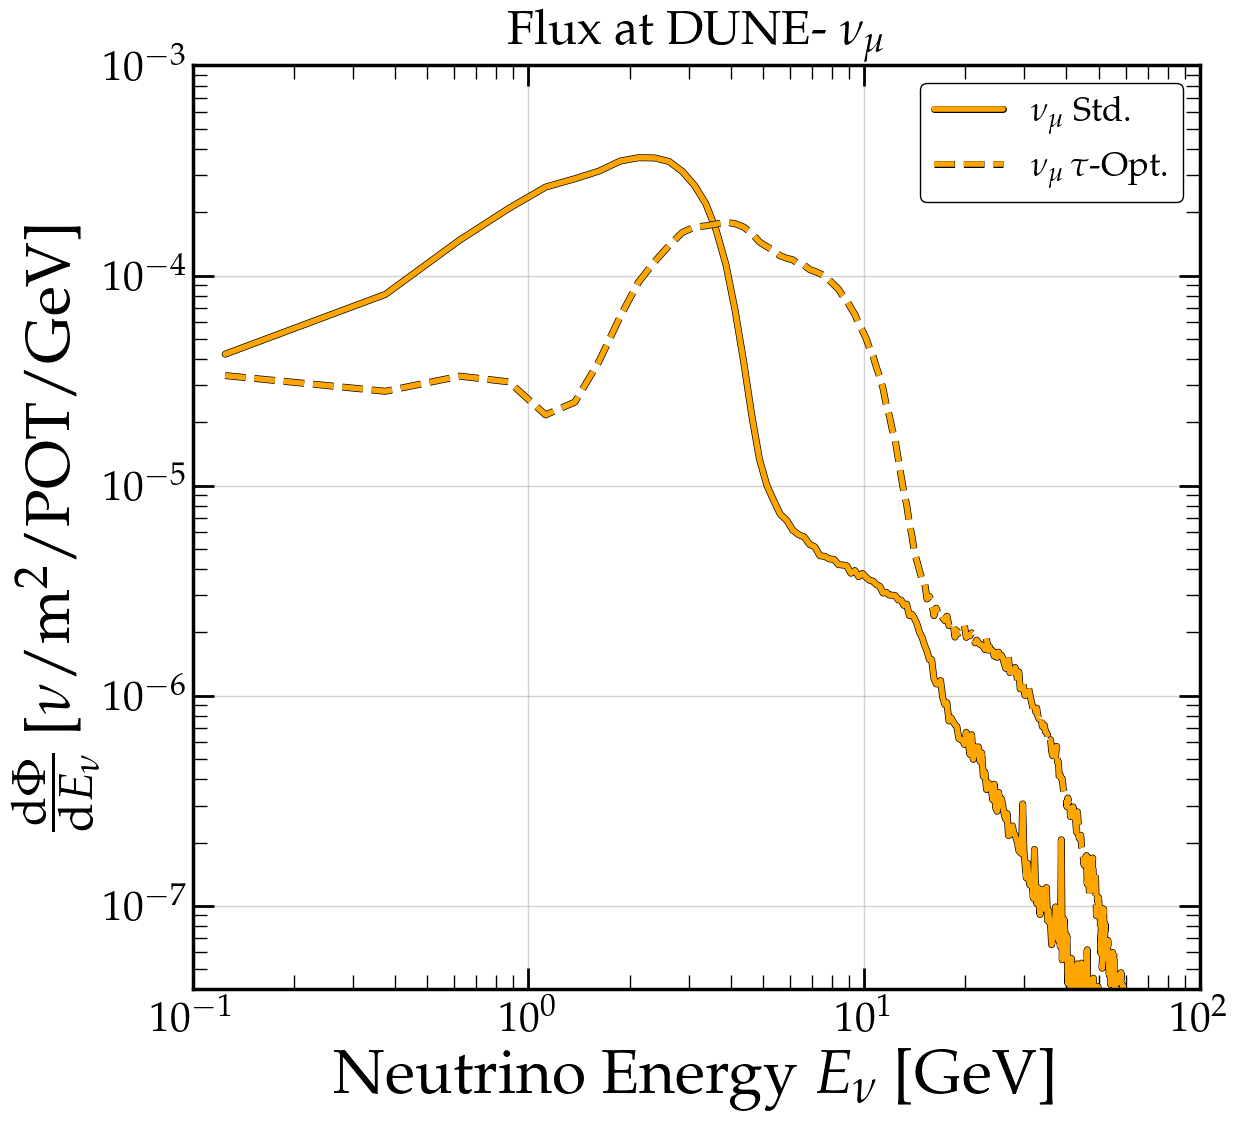

In [15]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Enu_Std_DUNE, numu_flux_Std_DUNE, color='orange', lw=4, ls='-', label=r'$\nu_\mu$ Std.', path_effects=[pe.Stroke(linewidth=5, foreground='k'), pe.Normal()])
ax.plot(Enu_TOPT_DUNE, numu_flux_TOPT_DUNE, color='orange', lw=4, ls='--', label=r'$\nu_\mu \, \tau$-Opt.', path_effects=[pe.Stroke(linewidth=5, foreground='k'), pe.Normal()])


ax.set_yscale('log')
ax.set_ylim(bottom=4e-8, top=1e-3)
ax.set_xscale('log')
ax.set_xlim(left=1e-1, right=1e2)
ax.xaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)
ax.yaxis.grid(True, ls='-', which='major', color='gray', alpha=0.35)
ax.legend(fontsize=25, loc='upper right', frameon=True, framealpha=1, edgecolor='k', fancybox=True)
ax.tick_params(which='both', right=True, top=True)
ax.set_xlabel(r'Neutrino Energy $E_\nu$ [GeV]')
ax.set_ylabel(r'$\frac{\mathrm{d} \Phi}{\mathrm{d} E_\nu}$  [$\nu$/m$^2$/POT/GeV]')
ax.set_title(r'Flux at DUNE- $\nu_\mu$', pad=15)

plt.savefig('../Plots/Figures_PDF/FluxatDUNE.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/FluxatDUNE.png', transparent=False, bbox_inches='tight')